# 01 — Load and verify the dataset

Brain tumor MRI classification. This notebook covers Phase 1.1–1.4 of the plan:
confirm the dataset structure, count everything, check image properties, and look
at real samples.

Nothing here trains a model. The goal is to know exactly what the data is before
writing a single line of preprocessing.

In [1]:
# Rebuild state after a kernel restart, without re-running sections 1-6.
# Reads from data/manifest.csv rather than re-walking the filesystem.
import csv, random, json
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

with open("data/manifest.csv") as f:
    rows = list(csv.DictReader(f))

records = [(r["split"], r["class"], Path(r["path"])) for r in rows]
CLASSES = sorted({r["class"] for r in rows})
SPLITS  = ["Training", "Testing"]

print(f"Restored {len(records)} records, classes: {CLASSES}")

Restored 7200 records, classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 1. Environment check

Confirm the kernel is pointing at the project venv, not system Python.

In [1]:
import sys
import platform

print("Python :", sys.version.split()[0])
print("Kernel :", sys.executable)
print("Machine:", platform.machine())

Python : 3.13.5
Kernel : /Users/sanaataneja/Desktop/Summer/tumor-identification-project/.venv/bin/python
Machine: arm64


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("numpy     :", np.__version__)

try:
    import torch
    print("torch     :", torch.__version__)
    if torch.backends.mps.is_available():
        print("device    : mps (Apple Silicon GPU)")
    elif torch.cuda.is_available():
        print("device    : cuda ->", torch.cuda.get_device_name(0))
    else:
        print("device    : cpu")
except ImportError:
    print("torch     : not installed yet (fine for this notebook)")

numpy     : 2.5.1
torch     : not installed yet (fine for this notebook)


## 2. Download the dataset

`kagglehub` downloads to a shared cache outside the repo and returns the path,
so there is no chance of accidentally committing ~150MB of JPEGs to git.

**Authentication:** the first call will prompt for credentials. Generate a legacy
API key from your Kaggle account settings page (API section), which downloads a
`kaggle.json`. Place it at `~/.kaggle/kaggle.json` and run `chmod 600` on it.

Run this once. Subsequent calls read from the cache and return instantly.

In [6]:
import kagglehub

DATASET_SLUG = "masoudnickparvar/brain-tumor-mri-dataset"

root = kagglehub.dataset_download(DATASET_SLUG)
print("Downloaded to:", root)

Downloaded to: /Users/sanaataneja/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2


In [7]:
from pathlib import Path

ROOT = Path(root)

# Some Kaggle datasets nest everything one level deep. Find the real root.
if not (ROOT / "Training").exists():
    candidates = [p for p in ROOT.rglob("Training") if p.is_dir()]
    if candidates:
        ROOT = candidates[0].parent
        print("Adjusted root to:", ROOT)
    else:
        raise FileNotFoundError("No 'Training' directory found. Inspect the tree below.")

print("Using root:", ROOT)

Using root: /Users/sanaataneja/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2


## 3. Confirm the folder structure

Expecting `Training/` and `Testing/`, each with four class subfolders.

In [8]:
def show_tree(path, prefix="", max_files=0):
    entries = sorted(path.iterdir())
    dirs = [e for e in entries if e.is_dir()]
    files = [e for e in entries if e.is_file()]
    for d in dirs:
        n = sum(1 for _ in d.rglob("*") if _.is_file())
        print(f"{prefix}{d.name}/  ({n} files)")
        show_tree(d, prefix + "    ", max_files)
    for f in files[:max_files]:
        print(f"{prefix}{f.name}")

show_tree(ROOT)

Testing/  (1600 files)
    glioma/  (400 files)
    meningioma/  (400 files)
    notumor/  (400 files)
    pituitary/  (400 files)
Training/  (5600 files)
    glioma/  (1400 files)
    meningioma/  (1400 files)
    notumor/  (1400 files)
    pituitary/  (1400 files)


In [9]:
SPLITS = ["Training", "Testing"]
CLASSES = sorted([p.name for p in (ROOT / "Training").iterdir() if p.is_dir()])

print("Splits :", SPLITS)
print("Classes:", CLASSES)

# Sanity: both splits must have identical class folders
assert CLASSES == sorted([p.name for p in (ROOT / "Testing").iterdir() if p.is_dir()]), \
    "Train and test class folders differ"
print("\nClass folders match across splits.")

Splits : ['Training', 'Testing']
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Class folders match across splits.


## 4. Count everything

How many images per class, and how imbalanced is it?

In [10]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

def list_images(split, cls):
    return [p for p in (ROOT / split / cls).iterdir()
            if p.suffix.lower() in IMG_EXT]

counts = {s: {c: len(list_images(s, c)) for c in CLASSES} for s in SPLITS}

print(f"{'class':<14}{'train':>8}{'test':>8}{'total':>8}{'train %':>10}")
print("-" * 48)
train_total = sum(counts["Training"].values())
for cls in CLASSES:
    tr, te = counts["Training"][cls], counts["Testing"][cls]
    print(f"{cls:<14}{tr:>8}{te:>8}{tr+te:>8}{100*tr/train_total:>9.1f}%")
print("-" * 48)
test_total = sum(counts["Testing"].values())
print(f"{'TOTAL':<14}{train_total:>8}{test_total:>8}{train_total+test_total:>8}")

imbalance = max(counts["Training"].values()) / min(counts["Training"].values())
print(f"\nImbalance ratio (largest/smallest class in train): {imbalance:.2f}x")
print(f"Majority-class baseline accuracy on test: "
      f"{100*max(counts['Testing'].values())/test_total:.1f}%")

class            train    test   total   train %
------------------------------------------------
glioma            1400     400    1800     25.0%
meningioma        1400     400    1800     25.0%
notumor           1400     400    1800     25.0%
pituitary         1400     400    1800     25.0%
------------------------------------------------
TOTAL             5600    1600    7200

Imbalance ratio (largest/smallest class in train): 1.00x
Majority-class baseline accuracy on test: 25.0%


**Write down that baseline number.** It is the floor your model has to beat.
An accuracy below it means the model has learned nothing.

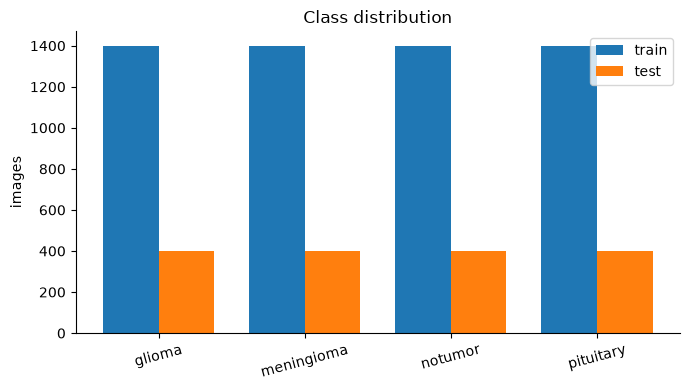

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(CLASSES))
w = 0.38
ax.bar(x - w/2, [counts["Training"][c] for c in CLASSES], w, label="train")
ax.bar(x + w/2, [counts["Testing"][c] for c in CLASSES], w, label="test")
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=15)
ax.set_ylabel("images"); ax.set_title("Class distribution")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 5. Image properties

Sizes, channels, and value ranges. This is what justifies the resize and
normalization steps.

In [12]:
import random
from collections import Counter

random.seed(42)

records = []
for split in SPLITS:
    for cls in CLASSES:
        for p in list_images(split, cls):
            records.append((split, cls, p))

print(f"Indexed {len(records)} images total.")

# Sampling keeps this fast; raise n for a full pass.
n = 800
sample = random.sample(records, min(n, len(records)))

sizes, modes = [], Counter()
for split, cls, p in sample:
    with Image.open(p) as im:
        sizes.append(im.size)          # (width, height)
        modes[im.mode] += 1

widths = np.array([s[0] for s in sizes])
heights = np.array([s[1] for s in sizes])

print(f"\nSampled {len(sample)} images")
print(f"width  : min {widths.min()}  max {widths.max()}  median {int(np.median(widths))}")
print(f"height : min {heights.min()}  max {heights.max()}  median {int(np.median(heights))}")
print(f"square : {100*np.mean(widths == heights):.1f}% of sampled images")
print(f"\nPIL modes: {dict(modes)}")
print("  L = 8-bit grayscale, RGB = 3-channel")

Indexed 7200 images total.

Sampled 800 images
width  : min 150  max 1338  median 512
height : min 168  max 1304  median 512
square : 79.6% of sampled images

PIL modes: {'RGB': 454, 'L': 345, 'RGBA': 1}
  L = 8-bit grayscale, RGB = 3-channel


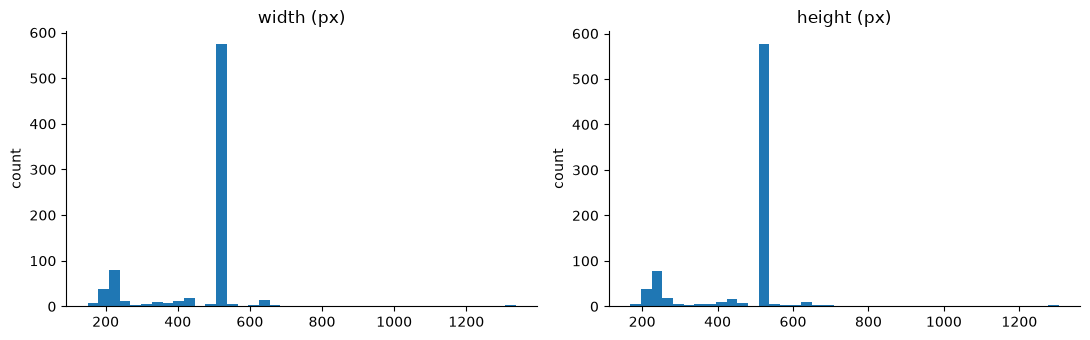

Sizes vary -> resizing is required before batching.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(widths, bins=40); axes[0].set_title("width (px)")
axes[1].hist(heights, bins=40); axes[1].set_title("height (px)")
for a in axes:
    a.set_ylabel("count"); a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("Sizes vary -> resizing is required before batching.")

In [14]:
# Are RGB images actually grayscale stored in 3 channels?
rgb_paths = [p for _, _, p in sample if Image.open(p).mode == "RGB"][:30]

identical = 0
for p in rgb_paths:
    a = np.array(Image.open(p))
    if np.array_equal(a[..., 0], a[..., 1]) and np.array_equal(a[..., 1], a[..., 2]):
        identical += 1

if rgb_paths:
    print(f"{identical}/{len(rgb_paths)} RGB images have identical channels "
          f"(i.e. grayscale stored as RGB)")
else:
    print("No RGB images in the sample - all single-channel.")

28/30 RGB images have identical channels (i.e. grayscale stored as RGB)


In [18]:
# Value range check
arr = np.array(Image.open(sample[0][2]).convert("L"))
print("dtype:", arr.dtype)
print("range:", arr.min(), "->", arr.max())
print("shape:", arr.shape)

dtype: uint8
range: 0 -> 255
shape: (512, 512)


In [15]:
#widening RGB check to look at the 2 anomalies 
from collections import defaultdict

colored = []
for split, cls, p in records:
    with Image.open(p) as im:
        if im.mode not in ("RGB", "RGBA"):
            continue
        a = np.array(im.convert("RGB"))
        if not (np.array_equal(a[..., 0], a[..., 1]) and
                np.array_equal(a[..., 1], a[..., 2])):
            colored.append((split, cls, p))

print(f"{len(colored)} genuinely colored images out of {len(records)}")

by_class = defaultdict(int)
for split, cls, _ in colored:
    by_class[(split, cls)] += 1
for k, v in sorted(by_class.items()):
    print(f"  {k[0]:<10} {k[1]:<14} {v}")

128 genuinely colored images out of 7200
  Testing    notumor        38
  Training   notumor        90


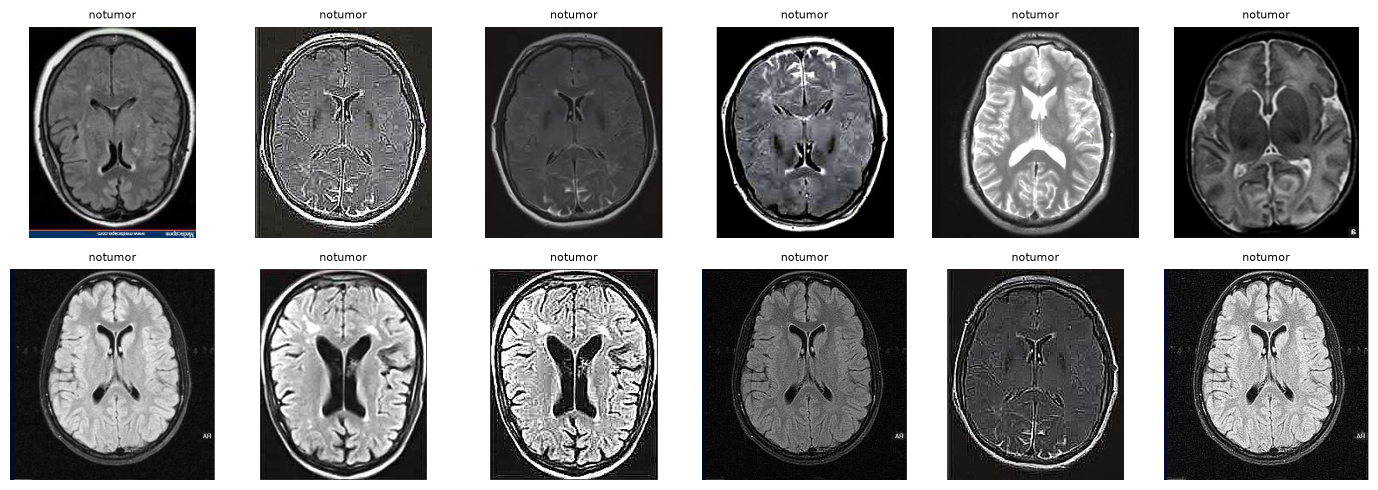

In [16]:
show = colored[:12]
if show:
    fig, axes = plt.subplots(2, 6, figsize=(14, 5))
    for ax, (split, cls, p) in zip(axes.ravel(), show):
        ax.imshow(Image.open(p).convert("RGB"))
        ax.set_title(f"{cls}", fontsize=8)
        ax.axis("off")
    for ax in axes.ravel()[len(show):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

### Source leakage check

All 128 colored images fall in `notumor`, suggesting that class comes from a
different source dataset. If the classes are separable at 8x8 resolution —
where no anatomy survives — the labels are confounded with source-level image
statistics rather than pathology (doesn't consider tumors and instead considers 
different invisible image characteristics)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X, y = [], []
for split, cls, p in random.sample(records, 2000):
    im = Image.open(p).convert("L").resize((8, 8))
    X.append(np.array(im).ravel() / 255.0)
    y.append(cls)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25,
                                      stratify=y, random_state=42)
clf = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
print(f"8x8 accuracy: {clf.score(Xte, yte):.3f}")
print(f"majority baseline: {max(np.bincount(np.unique(y, return_inverse=True)[1]))/len(y):.3f}")

8x8 accuracy: 0.650
majority baseline: 0.262


In [20]:
# Border-only leakage test.
# If the classes are separable using ONLY the empty background around the head,
# the model is reading source artifacts (watermarks, compression, padding),
# not anatomy. There is no legitimate diagnostic signal in background pixels.

Xb, yb = [], []
for split, cls, p in random.sample(records, 2000):
    # Grayscale, shrink to 32x32, scale pixels to 0-1.
    # Small size keeps this fast and coarsens any real anatomical detail.
    a = np.array(Image.open(p).convert("L").resize((32, 32))) / 255.0

    # Extract only the outer 3-pixel frame, discarding the 26x26 interior
    # where the brain sits. Four slices, flattened and joined:
    frame = np.concatenate([
        a[:3].ravel(),          # top 3 rows (full width)
        a[-3:].ravel(),         # bottom 3 rows (full width)
        a[3:-3, :3].ravel(),    # left 3 cols, excluding rows already taken
        a[3:-3, -3:].ravel(),   # right 3 cols, same exclusion
    ])                          # -> 348 features, zero brain tissue

    Xb.append(frame)
    yb.append(cls)

# stratify keeps class proportions equal across the split;
# random_state makes the result reproducible across reruns.
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.25,
                                      stratify=yb, random_state=42)

# Logistic regression, not a CNN: if even a linear model on background pixels
# beats the 0.262 majority baseline, the artifact is blatant.
clf_border = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
print(f"border-only accuracy: {clf_border.score(Xte, yte):.3f}")
print(f"majority baseline:    0.262")

border-only accuracy: 0.634
majority baseline:    0.262


In [21]:
# 1. Which class does the border identify?
from sklearn.metrics import confusion_matrix
print(CLASSES)
print(confusion_matrix(yte, clf_border.predict(Xte), labels=CLASSES))

['glioma', 'meningioma', 'notumor', 'pituitary']
[[86 23 12  5]
 [56 41 12 14]
 [16  6 95  7]
 [12 14  6 95]]


## 6. Look at the images

Do not skip this. You are checking for black margins, burned-in scanner text,
mixed acquisition planes, and anything corrupted.

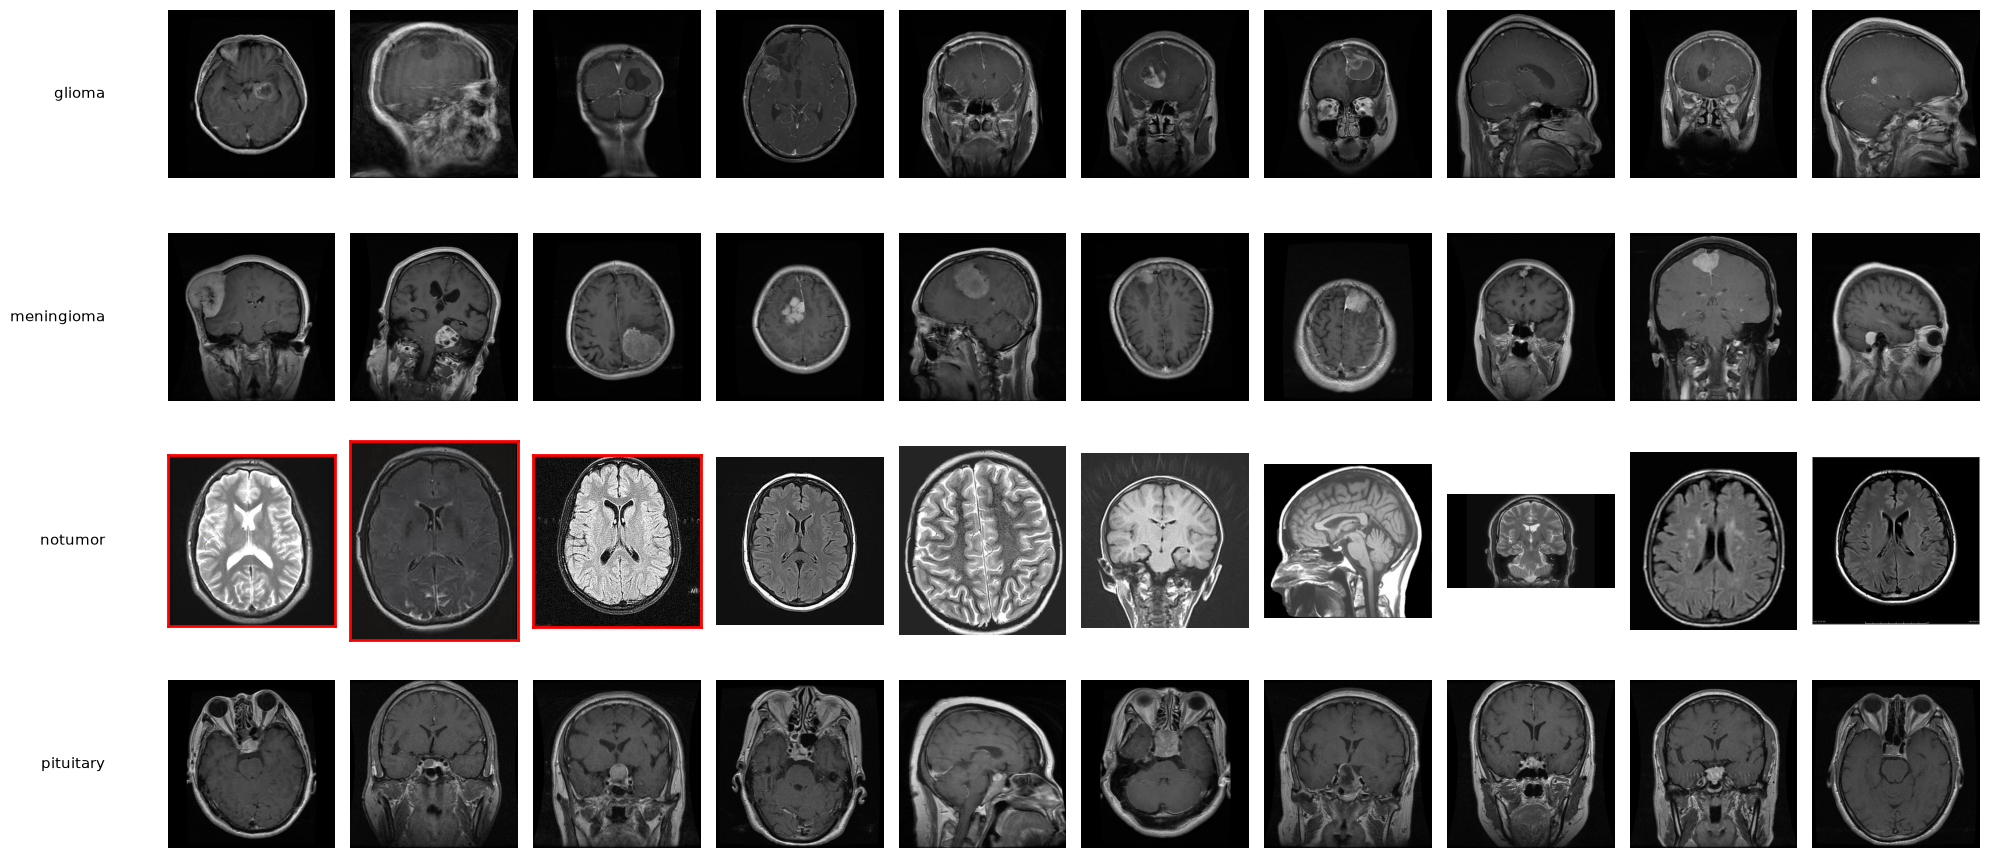

Red frame = image has genuinely colored channels (watermark/overlay)


In [22]:
N = 10                       # samples per class
COLORED_SLOTS = 3            # of those, how many drawn from the colored set

# Path lookup for the colored (watermarked) images, so we can force them
# into the notumor row instead of relying on random sampling to find them.
colored_by_class = {}
for split, cls, p in colored:
    if split == "Training":
        colored_by_class.setdefault(cls, []).append(p)

fig, axes = plt.subplots(len(CLASSES), N, figsize=(2.0 * N, 2.3 * len(CLASSES)))

for r, cls in enumerate(CLASSES):
    pool = list_images("Training", cls)
    forced = colored_by_class.get(cls, [])

    # Take up to COLORED_SLOTS known-colored images, fill the rest randomly
    # from images we haven't already picked.
    picks = random.sample(forced, min(COLORED_SLOTS, len(forced)))
    remaining = [p for p in pool if p not in set(picks)]
    picks += random.sample(remaining, N - len(picks))

    for j, p in enumerate(picks):
        ax = axes[r, j]
        # convert("RGB") so watermark colour is visible; cmap is ignored for RGB
        ax.imshow(Image.open(p).convert("RGB"))
        ax.set_xticks([]); ax.set_yticks([])
        # Red frame marks an image from the colored set
        is_colored = p in set(forced)
        for s in ax.spines.values():
            s.set_color("red" if is_colored else "none")
            s.set_linewidth(2)

    axes[r, 0].set_ylabel(cls, fontsize=11, rotation=0,
                          ha="right", va="center", labelpad=45)

plt.tight_layout(); plt.show()
print("Red frame = image has genuinely colored channels (watermark/overlay)")

### What to record from the grid above

Answer these in the cell below, in your own words. This becomes the findings
section of your EDA writeup.

1. How much black margin surrounds the brain, and does it vary a lot?
2. Do you see burned-in text, arrows, or scale bars? Where?
3. Which acquisition planes appear (axial / sagittal / coronal)? Is it mixed
   within a class?
4. Can *you* tell the classes apart by eye? If not, what would a model key on?
5. Anything that looks corrupted, duplicated, or mislabeled?

_Findings:_

1. Black margins seem to appear the most in glioma and meningioma tumors, with the least amount in the pituitary class. A varying amount of black margins appear in the no tumor class. 
2. There are no arrows or scale bars but there are watermarks present in a few images from the no tumor class.
3. Axial, sagittal, and coronal appear in all four classes. Overall, the sagittal plane appears the least, with the axial plane appearing the most. 
4. The pituitary class can be distinguished because of the lower axial views highlighting the pituitary gland. The no tumor class can also be distinguished. The glioma and meningioma classes are not easy to distinguish and can lead to problems with the model. 
5. No

## 7. Save a manifest

A CSV index of every image means later notebooks never have to re-walk the
filesystem, and your splits stay reproducible.

In [23]:
import csv

out = Path("data")
out.mkdir(exist_ok=True)
manifest = out / "manifest.csv"

with open(manifest, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["split", "class", "path"])
    for split, cls, p in records:
        w.writerow([split, cls, str(p)])

print(f"Wrote {len(records)} rows to {manifest.resolve()}")
print("\nNote: paths are absolute and machine-specific.")
print("Regenerate this notebook's output rather than committing the CSV.")

Wrote 7200 rows to /Users/sanaataneja/Desktop/Summer/tumor-identification-project/notebooks/data/manifest.csv

Note: paths are absolute and machine-specific.
Regenerate this notebook's output rather than committing the CSV.


## 8. Near-duplicate detection

In [2]:
# Near-duplicate detection.
# The dataset has no patient IDs, so we cannot split by patient. Perceptual
# hashing gives us an image-similarity proxy: adjacent slices from the same
# brain look nearly identical and will hash to nearby values.

import imagehash
from collections import defaultdict

# phash (perceptual hash) converts each image to a 64-bit fingerprint via a DCT.
# Unlike a file checksum, it is robust to resizing, mild brightness shifts, and
# JPEG re-encoding — so it catches "same scan, slightly different export"
# as well as literal duplicates.
HASH_SIZE = 8          # 8x8 DCT -> 64-bit hash
THRESHOLD = 6          # max Hamming distance to call two images near-duplicates

hashes = {}            # path -> ImageHash
meta = {}              # path -> (split, class)

for split, cls, p in records:
    with Image.open(p) as im:
        hashes[p] = imagehash.phash(im.convert("L"), hash_size=HASH_SIZE)
    meta[p] = (split, cls)

print(f"Hashed {len(hashes)} images.")

# Exact collisions first — these are literal duplicates, hash distance 0.
buckets = defaultdict(list)
for p, h in hashes.items():
    buckets[str(h)].append(p)

exact = {k: v for k, v in buckets.items() if len(v) > 1}
n_exact = sum(len(v) for v in exact.values()) - len(exact)
print(f"Exact hash collisions: {len(exact)} groups, {n_exact} redundant images.")

Hashed 7200 images.
Exact hash collisions: 592 groups, 988 redundant images.


In [3]:
# This is the check that can invalidate your headline metric.
# If a test image has a near-identical twin in Training, the model has
# effectively seen it during training and your reported test accuracy is
# inflated. No split of your own can fix this — it's baked into the dataset.

train_paths = [p for p in hashes if meta[p][0] == "Training"]
test_paths  = [p for p in hashes if meta[p][0] == "Testing"]

# Pack hashes into a numpy bit-matrix so we can compare all pairs at once.
# Comparing 5,700 x 1,300 pairs in a Python loop would take minutes;
# vectorized XOR-and-popcount takes seconds.
def to_bits(paths):
    return np.array([hashes[p].hash.flatten() for p in paths], dtype=np.uint8)

Btr, Bte = to_bits(train_paths), to_bits(test_paths)

# Hamming distance = number of differing bits.
# Broadcasting: (n_test, 1, 64) XOR (1, n_train, 64) -> (n_test, n_train, 64)
# We chunk over test images to keep peak memory reasonable.
cross_hits = []
CHUNK = 200
for i in range(0, len(Bte), CHUNK):
    chunk = Bte[i:i+CHUNK]
    dist = (chunk[:, None, :] != Btr[None, :, :]).sum(axis=2)
    for r, c in zip(*np.where(dist <= THRESHOLD)):
        cross_hits.append((test_paths[i + r], train_paths[c], int(dist[r, c])))

print(f"Test images with a near-duplicate in Training: "
      f"{len({t for t, _, _ in cross_hits})} of {len(test_paths)} "
      f"({100 * len({t for t, _, _ in cross_hits}) / len(test_paths):.1f}%)")

# Break it down by class — leakage may be concentrated in one source.
by_cls = defaultdict(set)
for t, _, _ in cross_hits:
    by_cls[meta[t][1]].add(t)
for cls in CLASSES:
    n = len(by_cls[cls])
    total = sum(1 for p in test_paths if meta[p][1] == cls)
    print(f"  {cls:<14} {n:>4} / {total:<4} ({100*n/total:.1f}%)")

Test images with a near-duplicate in Training: 981 of 1600 (61.3%)
  glioma          172 / 400  (43.0%)
  meningioma      240 / 400  (60.0%)
  notumor         363 / 400  (90.8%)
  pituitary       206 / 400  (51.5%)


In [4]:
# Group near-duplicates within Training into clusters, then treat each cluster
# as one unit when splitting. This approximates patient-level splitting using
# image similarity instead of the patient IDs we don't have.

# Union-Find: merges any two images within THRESHOLD into the same cluster,
# transitively. If A~B and B~C, all three land together even if A and C
# are further apart — which is the behaviour we want for a slice stack.
parent = {p: p for p in train_paths}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]   # path compression
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

CHUNK = 200
for i in range(0, len(Btr), CHUNK):
    chunk = Btr[i:i+CHUNK]
    dist = (chunk[:, None, :] != Btr[None, :, :]).sum(axis=2)
    for r, c in zip(*np.where(dist <= THRESHOLD)):
        if i + r < c:                    # upper triangle only, skip self-pairs
            union(train_paths[i + r], train_paths[c])

clusters = defaultdict(list)
for p in train_paths:
    clusters[find(p)].append(p)

sizes = sorted((len(v) for v in clusters.values()), reverse=True)
print(f"{len(train_paths)} training images -> {len(clusters)} clusters")
print(f"Largest clusters: {sizes[:10]}")
print(f"Singletons: {sum(1 for s in sizes if s == 1)}")

# Save the cluster assignment for notebook 02's split.
import json
group_of = {str(p): find(p).name for p in train_paths}
Path("data").mkdir(exist_ok=True)
with open("data/train_groups.json", "w") as f:
    json.dump(group_of, f)
print("\nWrote data/train_groups.json — use with sklearn's GroupShuffleSplit.")

5600 training images -> 3036 clusters
Largest clusters: [108, 99, 59, 30, 27, 27, 26, 25, 22, 21]
Singletons: 2089

Wrote data/train_groups.json — use with sklearn's GroupShuffleSplit.


Random-pair Hamming distance:
    0.1th pct: 10
      1th pct: 16
      5th pct: 20
     25th pct: 24
     50th pct: 28
  mean: 27.6

Fraction of RANDOM pairs at distance <= 6: 0.03%


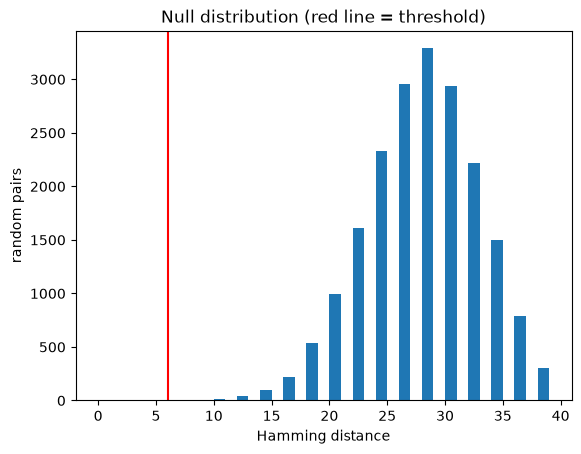

In [5]:
# What Hamming distance do RANDOM pairs of images have?
# If the natural distribution sits near our threshold, phash isn't
# discriminative on this data and 6 is meaningless as a cutoff.

rng = np.random.default_rng(0)
all_paths = list(hashes.keys())
B_all = np.array([hashes[p].hash.flatten() for p in all_paths], dtype=np.uint8)

idx_a = rng.integers(0, len(all_paths), 20000)
idx_b = rng.integers(0, len(all_paths), 20000)
keep = idx_a != idx_b
null_dist = (B_all[idx_a[keep]] != B_all[idx_b[keep]]).sum(axis=1)

print("Random-pair Hamming distance:")
for q in [0.1, 1, 5, 25, 50]:
    print(f"  {q:>5}th pct: {np.percentile(null_dist, q):.0f}")
print(f"  mean: {null_dist.mean():.1f}")
print(f"\nFraction of RANDOM pairs at distance <= 6: "
      f"{100 * (null_dist <= 6).mean():.2f}%")

plt.hist(null_dist, bins=range(0, 40)); plt.axvline(6, color="red")
plt.xlabel("Hamming distance"); plt.ylabel("random pairs")
plt.title("Null distribution (red line = threshold)"); plt.show()

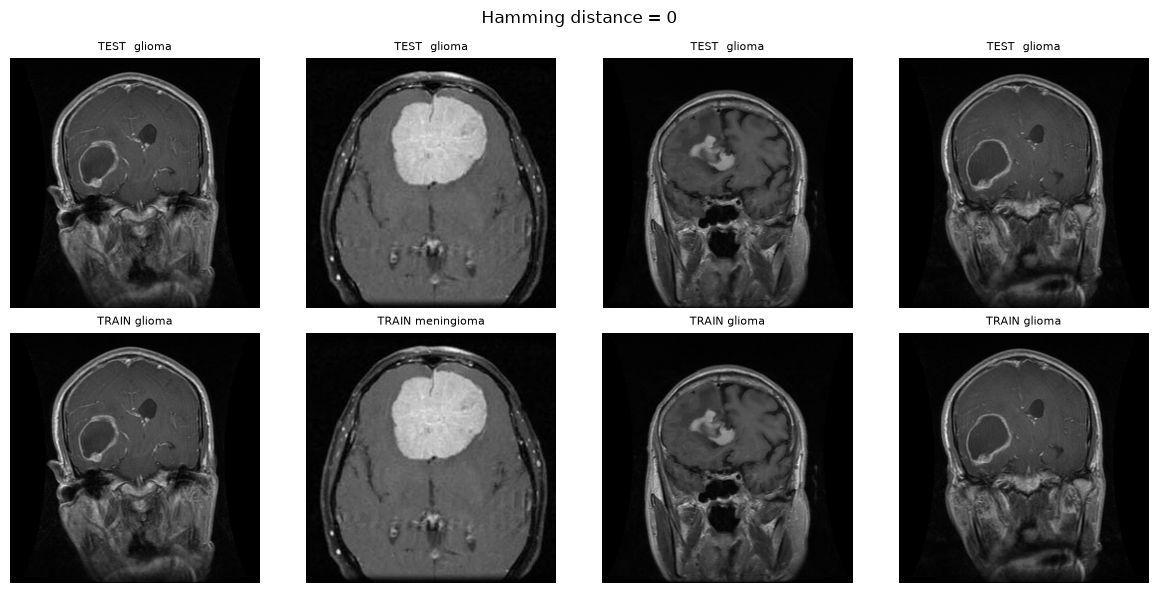

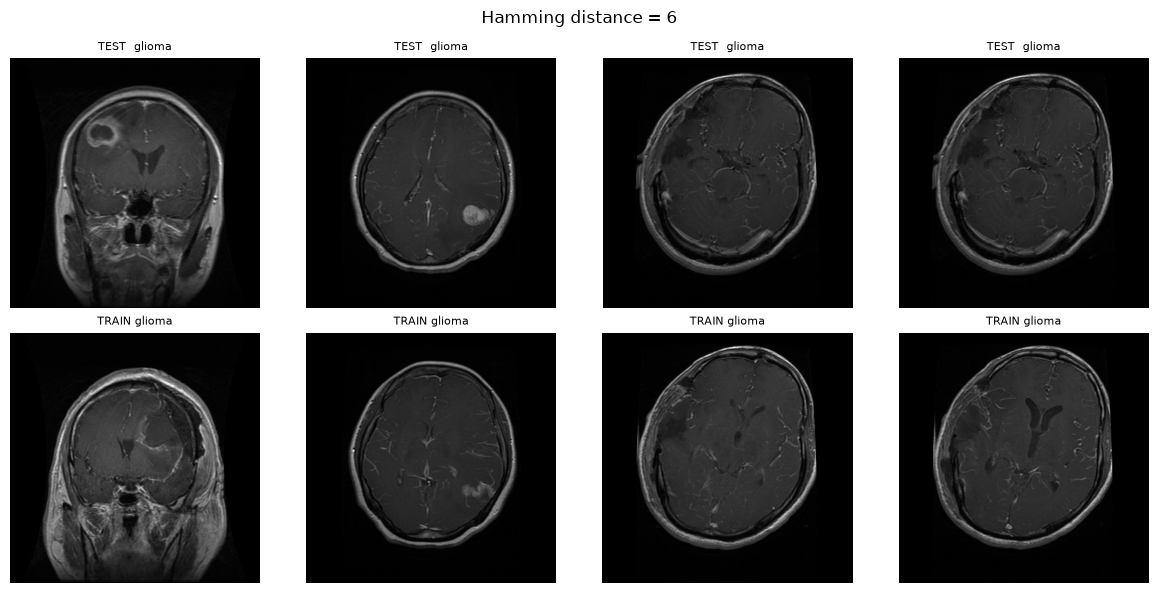

In [6]:
# Inspect flagged pairs at increasing distance. Are these the same brain?
for target_d in [0, 3, 6]:
    pairs = [(t, tr) for t, tr, d in cross_hits if d == target_d][:4]
    if not pairs: continue
    fig, axes = plt.subplots(2, len(pairs), figsize=(3*len(pairs), 6))
    axes = np.atleast_2d(axes)
    for j, (t, tr) in enumerate(pairs):
        axes[0, j].imshow(Image.open(t).convert("L"), cmap="gray")
        axes[0, j].set_title(f"TEST  {meta[t][1]}", fontsize=8)
        axes[1, j].imshow(Image.open(tr).convert("L"), cmap="gray")
        axes[1, j].set_title(f"TRAIN {meta[tr][1]}", fontsize=8)
        for a in (axes[0, j], axes[1, j]): a.axis("off")
    fig.suptitle(f"Hamming distance = {target_d}")
    plt.tight_layout(); plt.show()

In [7]:
# How fast does the flag rate fall as we tighten the threshold?
# We already know d=0 pairs are real duplicates and d=6 pairs are different
# brains, so the usable cutoff is somewhere in between. This shows the shape
# of that falloff — a sharp drop suggests a natural boundary, a gradual one
# means there isn't a clean separation and we should switch to a finer hash.

for T in range(0, 8):
    # cross_hits was built at THRESHOLD=6, so every pair with d<=6 is already
    # in it. Filtering down is free — no need to recompute distances.
    hits = {t for t, _, d in cross_hits if d <= T}
    print(f"  d<={T}: {len(hits):>4} / {len(test_paths)} test images "
          f"({100*len(hits)/len(test_paths):>5.1f}%)")

  d<=0:  370 / 1600 test images ( 23.1%)
  d<=1:  370 / 1600 test images ( 23.1%)
  d<=2:  505 / 1600 test images ( 31.6%)
  d<=3:  505 / 1600 test images ( 31.6%)
  d<=4:  714 / 1600 test images ( 44.6%)
  d<=5:  714 / 1600 test images ( 44.6%)
  d<=6:  981 / 1600 test images ( 61.3%)
  d<=7:  981 / 1600 test images ( 61.3%)


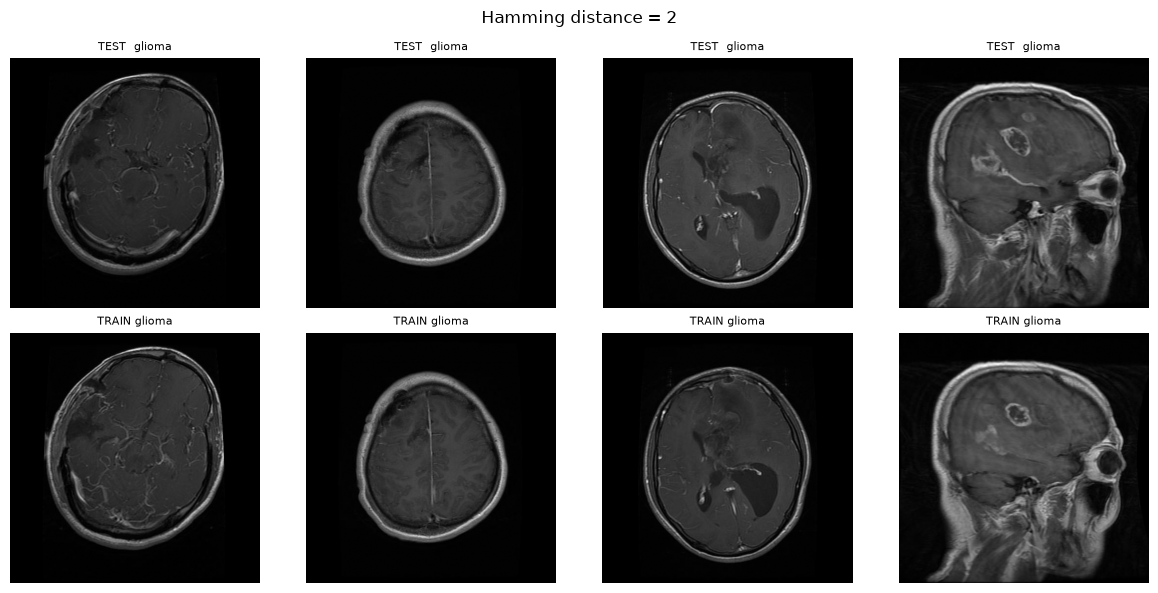

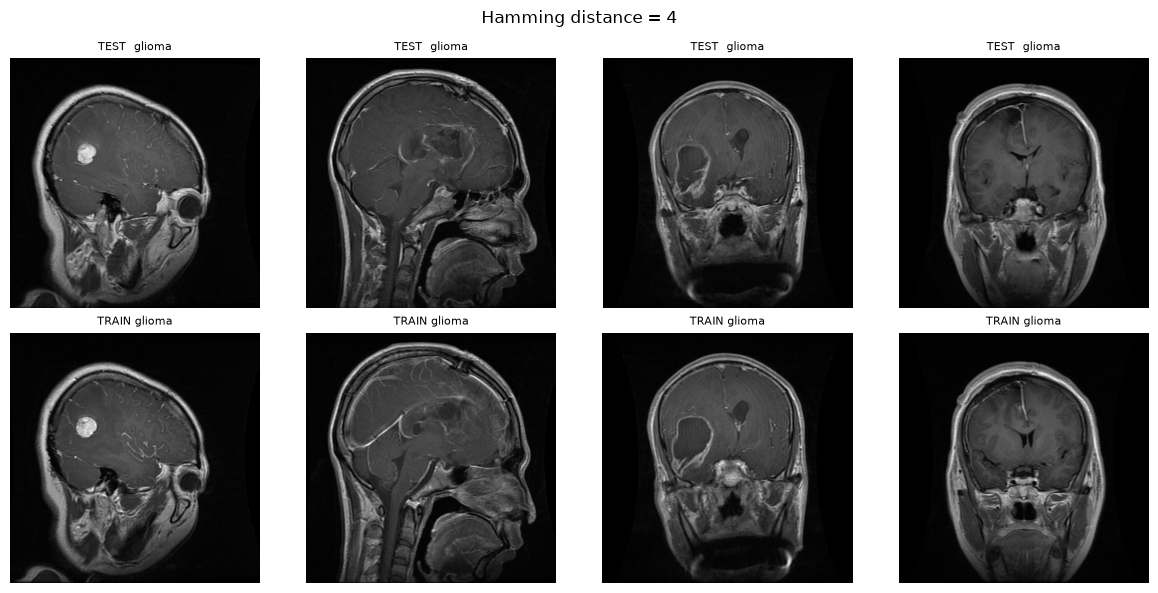

In [ ]:
# Manual inspection  — the null distribution was too
# permissive because it sampled across classes and protocols, while flagged
# pairs share all of those. 
#
# Look for: same skull outline, same ventricle shape, same lesion in a
# slightly shifted position (= adjacent slices, real duplicate) versus
# merely similar overall layout (= different patient, false positive).

for target_d in [1, 2, 3, 4]:
    # Exact distance, not <=, so each grid shows one distance in isolation.
    pairs = [(t, tr) for t, tr, d in cross_hits if d == target_d][:4]
    if not pairs:
        continue

    fig, axes = plt.subplots(2, len(pairs), figsize=(3*len(pairs), 6))
    # atleast_2d guards the len(pairs)==1 case, where subplots returns a 1-D
    # array and axes[0, j] would raise IndexError.
    axes = np.atleast_2d(axes)

    for j, (t, tr) in enumerate(pairs):
        # Top row = test image, bottom row = its flagged training match,
        # so each column is one pair read vertically.
        axes[0, j].imshow(Image.open(t).convert("L"), cmap="gray")
        axes[0, j].set_title(f"TEST  {meta[t][1]}", fontsize=8)
        axes[1, j].imshow(Image.open(tr).convert("L"), cmap="gray")
        axes[1, j].set_title(f"TRAIN {meta[tr][1]}", fontsize=8)
        for a in (axes[0, j], axes[1, j]):
            a.axis("off")

    fig.suptitle(f"Hamming distance = {target_d}")
    plt.tight_layout(); plt.show()

# Set THRESHOLD to the LARGEST distance where pairs still look like the same
# brain, then rerun cells 2 and 3 to regenerate cross_hits and train_groups.json.

In [9]:
#adjusting threshold to 4 after manual inspection and rerunning previous cells to regenerate cross_hits and train_groups.json. 
#hopefully avoids transitive chaining of duplicates 

THRESHOLD = 4

train_paths = [p for p in hashes if meta[p][0] == "Training"]
test_paths  = [p for p in hashes if meta[p][0] == "Testing"]

# Pack hashes into a numpy bit-matrix so we can compare all pairs at once.
# Comparing 5,700 x 1,300 pairs in a Python loop would take minutes;
# vectorized XOR-and-popcount takes seconds.
def to_bits(paths):
    return np.array([hashes[p].hash.flatten() for p in paths], dtype=np.uint8)

Btr, Bte = to_bits(train_paths), to_bits(test_paths)

# Hamming distance = number of differing bits.
# Broadcasting: (n_test, 1, 64) XOR (1, n_train, 64) -> (n_test, n_train, 64)
# We chunk over test images to keep peak memory reasonable.
cross_hits = []
CHUNK = 200
for i in range(0, len(Bte), CHUNK):
    chunk = Bte[i:i+CHUNK]
    dist = (chunk[:, None, :] != Btr[None, :, :]).sum(axis=2)
    for r, c in zip(*np.where(dist <= THRESHOLD)):
        cross_hits.append((test_paths[i + r], train_paths[c], int(dist[r, c])))

print(f"Test images with a near-duplicate in Training: "
      f"{len({t for t, _, _ in cross_hits})} of {len(test_paths)} "
      f"({100 * len({t for t, _, _ in cross_hits}) / len(test_paths):.1f}%)")

# Break it down by class — leakage may be concentrated in one source.
by_cls = defaultdict(set)
for t, _, _ in cross_hits:
    by_cls[meta[t][1]].add(t)
for cls in CLASSES:
    n = len(by_cls[cls])
    total = sum(1 for p in test_paths if meta[p][1] == cls)
    print(f"  {cls:<14} {n:>4} / {total:<4} ({100*n/total:.1f}%)")

Test images with a near-duplicate in Training: 714 of 1600 (44.6%)
  glioma           86 / 400  (21.5%)
  meningioma      173 / 400  (43.2%)
  notumor         353 / 400  (88.2%)
  pituitary       102 / 400  (25.5%)


In [10]:
# Group near-duplicates within Training into clusters, then treat each cluster
# as one unit when splitting. This approximates patient-level splitting using
# image similarity instead of the patient IDs we don't have.

# Union-Find: merges any two images within THRESHOLD into the same cluster,
# transitively. If A~B and B~C, all three land together even if A and C
# are further apart — which is the behaviour we want for a slice stack.
parent = {p: p for p in train_paths}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]   # path compression
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

CHUNK = 200
for i in range(0, len(Btr), CHUNK):
    chunk = Btr[i:i+CHUNK]
    dist = (chunk[:, None, :] != Btr[None, :, :]).sum(axis=2)
    for r, c in zip(*np.where(dist <= THRESHOLD)):
        if i + r < c:                    # upper triangle only, skip self-pairs
            union(train_paths[i + r], train_paths[c])

clusters = defaultdict(list)
for p in train_paths:
    clusters[find(p)].append(p)

sizes = sorted((len(v) for v in clusters.values()), reverse=True)
print(f"{len(train_paths)} training images -> {len(clusters)} clusters")
print(f"Largest clusters: {sizes[:10]}")
print(f"Singletons: {sum(1 for s in sizes if s == 1)}")

# Save the cluster assignment for notebook 02's split.
import json
group_of = {str(p): find(p).name for p in train_paths}
Path("data").mkdir(exist_ok=True)
with open("data/train_groups.json", "w") as f:
    json.dump(group_of, f)
print("\nWrote data/train_groups.json — use with sklearn's GroupShuffleSplit.")

5600 training images -> 3989 clusters
Largest clusters: [22, 19, 18, 16, 16, 16, 11, 11, 11, 11]
Singletons: 3201

Wrote data/train_groups.json — use with sklearn's GroupShuffleSplit.


In [11]:
# Test images with NO near-duplicate in Training, at the validated threshold.
leaked = {t for t, _, d in cross_hits if d <= THRESHOLD}
clean_test = [p for p in test_paths if p not in leaked]

print(f"Clean test images: {len(clean_test)} / {len(test_paths)} "
      f"({100*len(clean_test)/len(test_paths):.1f}%)")
for cls in CLASSES:
    n = sum(1 for p in clean_test if meta[p][1] == cls)
    print(f"  {cls:<14} {n}")

with open("data/clean_test.json", "w") as f:
    json.dump([str(p) for p in clean_test], f)

Clean test images: 886 / 1600 (55.4%)
  glioma         314
  meningioma     227
  notumor        47
  pituitary      298


## Next

`02_preprocessing.ipynb` — margin removal via contour extreme points, then
resize, then normalize. Build the crop function first and plot before/after on
20 real images before trusting it.